<div style="display: flex; align-items: center; justify-content: center; text-align: center;">
  <img src="https://coursereport-s3-production.global.ssl.fastly.net/uploads/school/logo/219/original/CT_LOGO_NEW.jpg" width="100" style="margin-right: 10px;">
  <div>
    <h1><b> Project - Airline-Satisfaction-Predictions</b></h1>
  </div>
</div>

## Pablo A. Herdener

# PART 2: MODELING
Now that the data is clean and analyzed, it can be used for Models building.

- **Establish baseline accuracy score:** Before training any models, establish a baseline accuracy score. This provides a benchmark for evaluating the performance of the Models.

- **Train-test-split with `random_state = 42`:** Split the data into training and testing sets using `train_test_split` with a specified random state. This ensures reproducibility in the results. The dataset is large, then an 80% / 20% split (default) will be used.

- **Normalize the data with `StandardScaler`:** Standardize the features using `StandardScaler` to ensure that they are on a similar scale. This step is particularly important for algorithms sensitive to the scale of input features, such as KNN.

- **Evaluate K-Nearest Neighbors (KNN):**
  - Set \( k = 5 \) and calculate the training/testing accuracy scores. Explore whether the model performs better with other values of \( k \). <br>
<br>
- **Try Logistic Regression and RandomForestClassifier:**
  - Experiment with alternative models such as Logistic Regression and RandomForestClassifier. Compare their performance against the KNN model to identify the most suitable algorithm for your specific classification task.
<br>
  - For each model, include a confusion matrix to assess its performance in terms of true positives, true negatives, false positives, and false negatives.

## 0. Load libraries and Reading the Dataset
---

Libraries Needed for Modeling:
1. `pandas`
2. `numpy`
3. `matplotlib` and `seaborn`
4. `KNeighborsClassifier` from `sklearn`'s `neighbors`
6. `train_test_split` from `sklearn`'s `model_selection`
7. `StandardScaler` from `sklearn`'s `preprocessing`
8. `ConfusionMatrixDisplay` from `sklearn`'s `metrics`
9. `LogisticRegression` from `sklearn`'s `linear_model`
10. `RandomForestClassifier` from `sklearn`'s `ensemble`

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Reading the Cleaned Dataset
df = pd.read_csv('data/cleaned_airline_passenger_satisfaction.csv')

In [3]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,3,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,3,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,3,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,3,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [4]:
df.shape

(97799, 23)

## 1. Establish Baseline Accuracy Score
---

In [5]:
df['satisfaction'].value_counts(normalize = True)

satisfaction
0    0.562081
1    0.437919
Name: proportion, dtype: float64

> We want to get a model that has a higher accuracy than 56.21%!

## 2. Train/Test split
---

Use the `train_test_split` function to split the cleaned data into a training set and a holdout set.

In [6]:
X = df.drop(columns = ['satisfaction'])
y = df['satisfaction']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)

## 3. Standard Scaler (for KNN and Logistic Regression)
---

In [8]:
# Instantiate StandardScaler
sc = StandardScaler()

In [9]:
# FIT AND TRANSFORM THE TRAINING SET
X_train_sc = sc.fit_transform(X_train)

# TRANSFORM the test set
X_test_sc = sc.transform(X_test)

## 4. Evaluate the KNN Model
 ---
First using the defaults for now and then analyze different k-values

In [10]:
knn = KNeighborsClassifier()

1. Fit the model to `X_train_sc`, `y_train`
2. Score it on `X_test_sc`, `y_test`

In [11]:
# Fit
knn.fit(X_train_sc, y_train)

KNeighborsClassifier()

In [12]:
# Training accuracy score
knn.score(X_train_sc, y_train)

0.9464614377837463

In [13]:
# Testing accuracy score
knn.score(X_test_sc, y_test)

0.9263394683026585

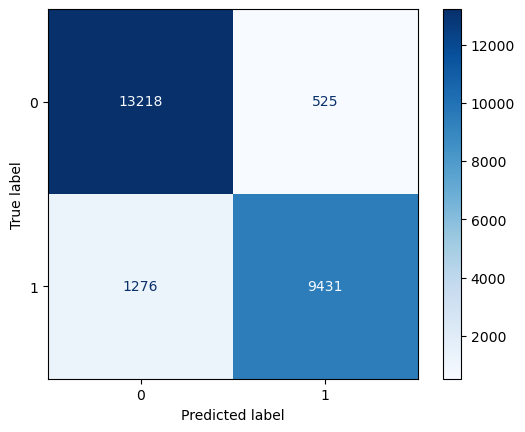

In [14]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn, X_test_sc, y_test, cmap = 'Blues')
plt.savefig("visualizations/10_KNN_confusion_matrix_k5", dpi=300, bbox_inches='tight')
plt.show()

- The accuracy score for the Scaled Test dataset is 92.63%, much better than the baseline of 56.21%.
- False Negative (FN): 1276 predicting the customers are unhappy when they are actually satisfied.
- False Positive (FP): 525 predicting the customers are happy when they are actually nutral/unsatisfied.

There are more FNs than FPs. This is better than the opposite because thinking a dissatisfied customer is satisfied prevents the company from addressing their concerns. 

- Catch as many neutral/dissatisfied customers as possible.
- Avoid missing unhappy customers.
- Prioritize service recovery.

The only disadvantage of having more FNs than FPs is if the intervention for “neutral/unsatisfied” customers is extremely expensive.

### Hyperparameter Tuning - Adjusting the value of 'k' 

In [15]:
# Reinstantiate and Scoring the Model with Default Parameters

knn = KNeighborsClassifier()
knn.fit(X_train_sc, y_train)
knn.score(X_test_sc, y_test)

0.9263394683026585

In [16]:
# Defining a function to set scores for given values of k.

scores = []
for k in range(3, 32, 2): # we want only odd numbers in k
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train_sc, y_train)
    train_score = knn.score(X_train_sc, y_train)
    test_score = knn.score(X_test_sc, y_test)

    scores.append({'k':k, 'train_score':train_score, 'test_score':test_score})

df_scores = pd.DataFrame(scores)

In [17]:
# Sorting values by test score (the relevant one). Best score is with k=17.

df_scores.sort_values(by = 'test_score', ascending = False)

,k,train_score,test_score
7,17,0.932433,0.927975
6,15,0.933210,0.927894
8,19,0.931519,0.927812
4,11,0.936155,0.927607
3,9,0.938104,0.927362
5,13,0.934641,0.927362
2,7,0.941213,0.926748
11,25,0.929461,0.926667
9,21,0.930360,0.926626
1,5,0.946461,0.926339


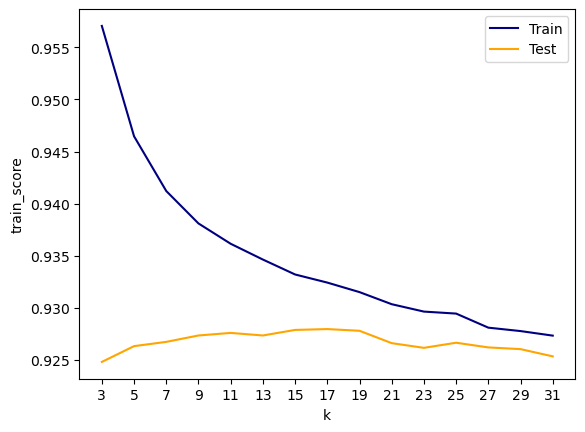

In [18]:
# Visualize this:
sns.lineplot(data = df_scores, x = 'k', y = 'train_score', c = 'navy', label = "Train")
sns.lineplot(data = df_scores, x = 'k', y = 'test_score', c = 'orange', label = "Test")
plt.xticks(range(3,32,2))

plt.savefig("visualizations/14_KNN_hyperparameters", dpi=300, bbox_inches='tight')
plt.show()

# When k=17 we have the best score in our model (we care for Test set)

In [19]:
# Instantiate (again) & Refit (again)
knn = KNeighborsClassifier(n_neighbors = 17)
knn.fit(X_train_sc, y_train)

KNeighborsClassifier(n_neighbors=17)

In [20]:
# New training score
knn.score(X_train_sc, y_train)

0.9324326166682573

In [21]:
# New testing score
knn.score(X_test_sc, y_test)

0.9279754601226994

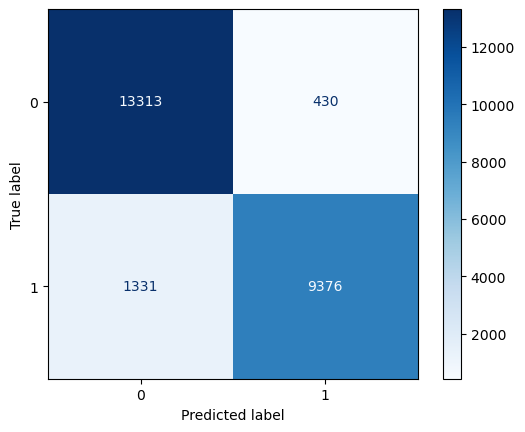

In [22]:
# New Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn, X_test_sc, y_test, cmap = 'Blues')
plt.savefig("visualizations/11_KNN_confusion_matrix_k17", dpi=300, bbox_inches='tight')
plt.show()

- The testing score is sligtly better than with the default k score, but less than 0.2% higher.
- However, the FNs are higher than the model with the default k, despite having less FPs.
- Recommend using this k value, because is better to have less FPs, business-wise (except if is too expensive the unsatisfied customers treatment). 

## 5. Evaluate other Models
 ---
Logistic Regression and Random Forest

### 5.1. Logistic Regression

In [23]:
# Instantiate and Fit the Model

logr = LogisticRegression()
logr.fit(X_train_sc, y_train)

LogisticRegression()

In [24]:
# Calculate Training Score
logr.score(X_train_sc, y_train)

0.8742723145509823

In [25]:
# Calculate Testing Score
logr.score(X_test_sc, y_test)

0.8779141104294479

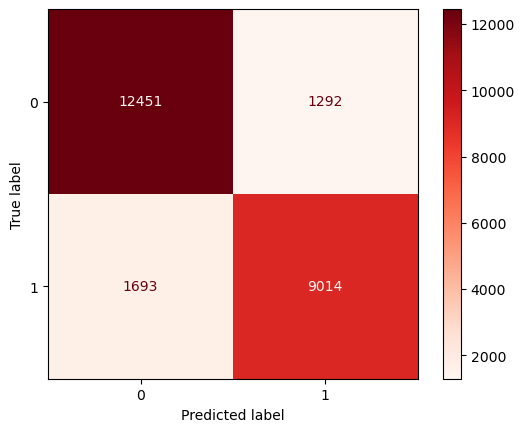

In [26]:
# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(logr, X_test_sc, y_test, cmap = 'Reds')
plt.savefig("visualizations/12_LR_confusion_matrix", dpi=300, bbox_inches='tight')
plt.show()

- The testing score is 87.79%, better than the Baseline but significantly worse than the KNN.
- Also, both FNs and FPs are higher than the KNN model.
- Recommend KNN Model up to this point.

### 5.2. Random Forest

In [27]:
# Instantiate and Fit the Model

rf = RandomForestClassifier()
rf.fit(X_train_sc, y_train)

RandomForestClassifier()

In [28]:
# Calculate Training Score
rf.score(X_train_sc, y_train)

1.0

In [29]:
# Calculate Testing Score
rf.score(X_test_sc, y_test)

0.9635173824130879

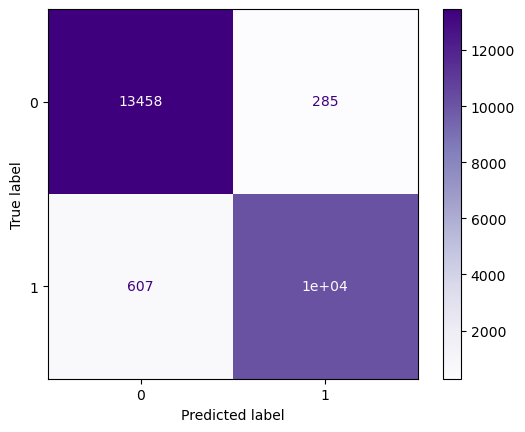

In [30]:
# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test_sc, y_test, cmap = 'Purples')
plt.savefig("visualizations/13_RF_confusion_matrix", dpi=300, bbox_inches='tight')
plt.show()

- The testing score is 96.25%, the best of all tested Models and the Baseline.
- Also, both FNs and FPs are the lowest than all the other Models, with only 618 FNs, less than half of the other Model's values.
- Recommend using Random Forest Model.

## 6. Summary of Model Evaluations

| Model	         | Accuracy | False Positives | False Negatives | Quick interpretation                    |
|----------------|----------|-----------------|-----------------|-----------------------------------------|
|KNN (k=5)|	0.9263|	525| 1276| Great Accuracy, more FNs than FPs, okay for the business model|
|KNN (k=17)| 0.9280| 430| 1331|	Slightly better accuracy than KNN (default), lower FPs than default k |
|Logistic Regression| 0.8743| 1292|	1693| The worst model in both Accuracy and Errorss|
|Random Forest|	0.9625|299|	618| The best model in both Accuracy and Errors|

- All models have good Accuracy > 0.87, much better than the 0.52 of the Baseline Model.
- The best model by FN, FP and Accuracy is Random Forest.
- Both KNN models have better scores and accuracy than Logistic Regression.
- Adjusting the k-value on KNN models can increase Accuravy and decreased FPs, desirable for business purposes.

### Conclusion

- The analysis explicitly states the model’s strong performance relative to baseline.
- It ties the FN vs FP pattern to business impact, not arbitrary preference.
- It also frames FN as “unnecessary but harmless,” and FP as “risky,” which is usually accurate for customer-experience applications and justifies keeping the model despite the imbalance.